Importing Required Librabry For The Project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Importing XL File For The Project And Viewing The First 5 Rows

In [2]:
df = pd.read_excel("Sample - Superstore for Tableau 9.x versions.xlsx", engine='openpyxl')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


###1. I used the .isna() function to check for any missing values in file before I proceed.

In [3]:
df.isna().values.any()

np.False_

###2. I checked for duplicate values in the file and showed all copies including the first occurance.

In [4]:
df[df.duplicated(keep=False)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


###3. I checked if any data needs correction in the file before proceeding to data processing.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

Grouping sales by month before plotting monthly sale line graph using Matplotlib showing Monthly Sales

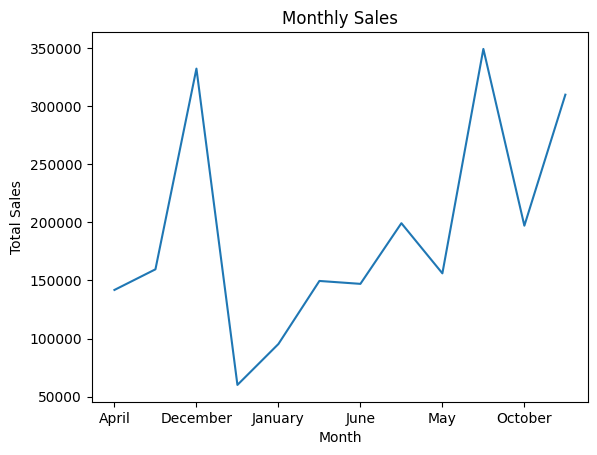

In [6]:
months = df["Order Date"].dt.month_name()
monthly_sales = df.groupby(months)["Sales"].sum()

monthly_sales.plot(kind="line")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

Plotting a Barchart showing Sales by Category

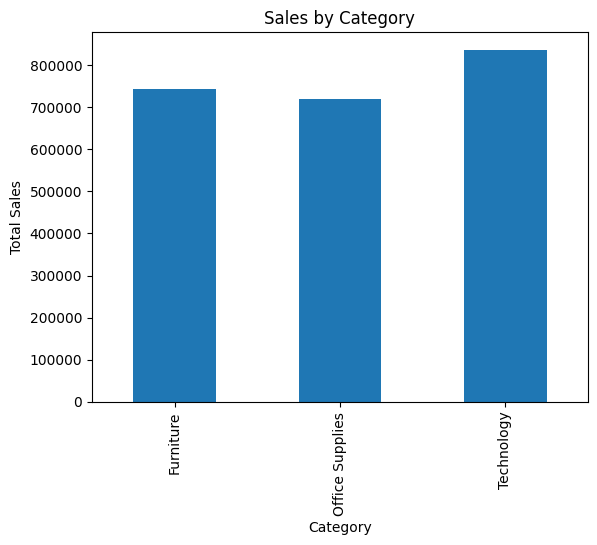

In [7]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

Plotting a Horizontal Bar Chart for Top 10 Products

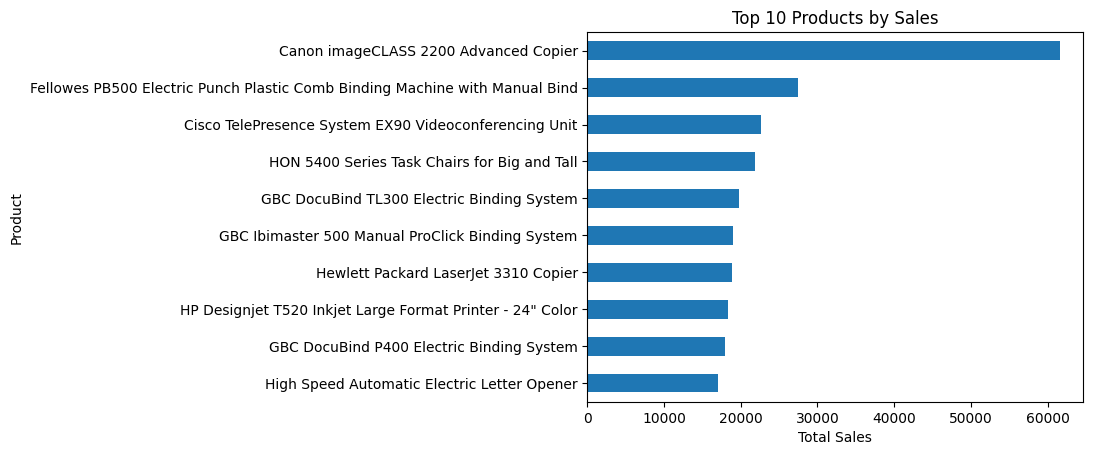

In [8]:
t10_products = (
    df.groupby("Product Name")["Sales"]
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .sort_values()
                )

t10_products.plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

Sales By Region Piechart

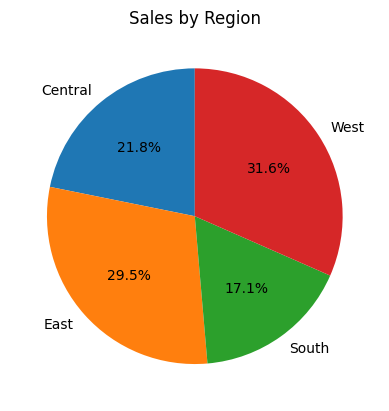

In [9]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(
                  kind="pie",
                  autopct = "%1.1f%%",
                  startangle= 90)

plt.title("Sales by Region")
#plt.ylabel("")
plt.show()

Profit By Category

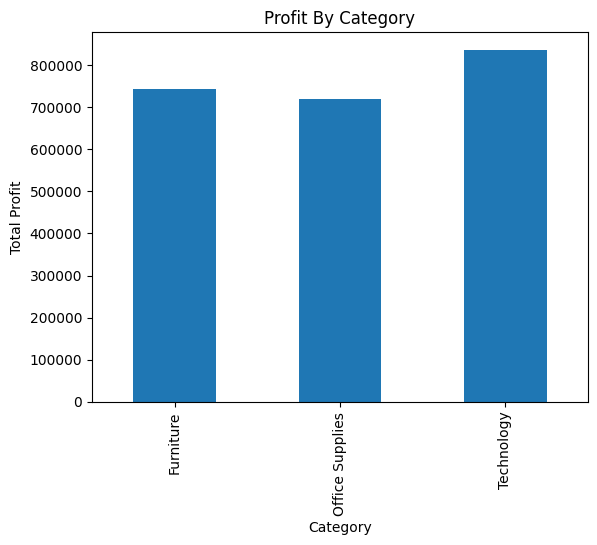

In [10]:
profit_cat = df.groupby("Category")["Sales"].sum()

profit_cat.plot(kind="bar")
plt.title("Profit By Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

In [11]:
df.to_excel("Sample - Superstore_Cleaned.xlsx", index=False)